In [1]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm import tqdm

DB = '../data/humans_clean.sqlite3'

WESTERN_COUNTRIES = {
    'United States', 'Washington, D.C.', 'Germany', 'France', 'Poland',
    'Netherlands', 'Kingdom of the Netherlands', 'United Kingdom', 'Wales',
    'Italy', 'Kingdom of Italy', 'Spain', 'Sweden', 'Norway', 'Finland',
    'Denmark', 'Faroe Islands', 'Austria', 'Belgium', 'Switzerland',
    'Portugal', 'Czech Republic', 'Slovakia', 'Greece', 'Hungary',
    'Ireland', 'Canada', 'Australia', 'New Zealand', 'Romania', 'Croatia',
    'Serbia', 'Slovenia', 'Lithuania', 'Latvia', 'Estonia', 'Bulgaria',
    'Iceland', 'Luxembourg', 'Liechtenstein', 'Andorra', 'Cyprus',
    'Vatican City', 'Weimar Republic', 'German Reich', 'internationality',
}

POLITIES = [
    ('Japan', 'Japan'),
    ('Ming Dynasty', 'Ming Dynasty'),
    ('Republic of Indonesia', 'Indonesia'),
    ('Republic of India', 'India'),
    ('Republic of Turkey', 'Turkey'),
    ('(Qing Dynasty);Qing Dynasty', 'Qing Dynasty'),
    ("People's Republic of China", "PRC"),
    ('Republic of Korea', 'South Korea'),
    ('Republic of Brazil', 'Brazil'),
    ('Tang Dynasty;(Tang Dynasty)', 'Tang Dynasty'),
    ('(Empire of Japan);Empire of Japan', 'Empire of Japan'),
    ('State of Israel', 'Israel'),
    ('Mexico;(Mexico)', 'Mexico'),
    ('Republic of China', 'Taiwan'),
    ('South Africa', 'South Africa'),
    ('Republic of Chile', 'Chile'),
    ('Ottoman Empire;(Ottoman Empire)', 'Ottoman Empire'),
    ('Islamic Republic of Iran', 'Iran'),
    ('Republic of Colombia', 'Colombia'),
    ('Republic of the Philippines', 'Philippines'),
]

In [2]:
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# Classify catalogs
cur = conn.execute('SELECT property_id, country_name FROM identifier_types')
western_pids = set()
non_western_pids = set()
for pid, country in cur:
    if country and country in WESTERN_COUNTRIES:
        western_pids.add(pid)
    elif country:
        non_western_pids.add(pid)

print(f"Western: {len(western_pids)}, Non-Western: {len(non_western_pids)}")

# Create temp tables
conn.execute('DROP TABLE IF EXISTS temp.w_pids')
conn.execute('CREATE TEMP TABLE w_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO w_pids VALUES (?)', [(p,) for p in western_pids])

conn.execute('DROP TABLE IF EXISTS temp.nw_pids')
conn.execute('CREATE TEMP TABLE nw_pids (pid TEXT PRIMARY KEY)')
conn.executemany('INSERT INTO nw_pids VALUES (?)', [(p,) for p in non_western_pids])

print("Pre-computing catalog coverage (2-3 min)...")
conn.execute('DROP TABLE IF EXISTS temp.ind_cat')
conn.execute('''
    CREATE TEMP TABLE ind_cat AS
    SELECT i.wikidata_id,
           MAX(CASE WHEN wp.pid IS NOT NULL THEN 1 ELSE 0 END) as has_western,
           MAX(CASE WHEN nwp.pid IS NOT NULL THEN 1 ELSE 0 END) as has_non_western
    FROM identifiers i
    LEFT JOIN w_pids wp ON i.property_id = wp.pid
    LEFT JOIN nw_pids nwp ON i.property_id = nwp.pid
    GROUP BY i.wikidata_id
''')
conn.execute('CREATE INDEX temp.idx_ind_cat ON ind_cat(wikidata_id)')
print("Done.")

Western: 1043, Non-Western: 394
Pre-computing catalog coverage (2-3 min)...


Done.


In [3]:
polity_data = []

for polity_name, display_name in tqdm(POLITIES):
    cur = conn.execute('''
        SELECT COALESCE(ic.has_western, 0), COALESCE(ic.has_non_western, 0)
        FROM individuals_cliopatria ip
        LEFT JOIN ind_cat ic ON ip.wikidata_id = ic.wikidata_id
        WHERE ip.polity_name = ?
    ''', (polity_name,))
    
    n_total, n_w_only, n_nw_only, n_both = 0, 0, 0, 0
    for hw, hnw in cur:
        n_total += 1
        if hw and hnw: n_both += 1
        elif hw: n_w_only += 1
        elif hnw: n_nw_only += 1
    
    if n_total > 0:
        polity_data.append({'polity': display_name, 'total': n_total,
                           'w_only': n_w_only, 'nw_only': n_nw_only, 'both': n_both})

for p in polity_data:
    print(f"{p['polity']:20} {p['total']:>8,} total, {p['w_only']+p['nw_only']+p['both']:>7,} with catalogs")

  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:01<00:35,  1.88s/it]

 10%|█         | 2/20 [00:02<00:18,  1.05s/it]

 15%|█▌        | 3/20 [00:02<00:13,  1.23it/s]

 20%|██        | 4/20 [00:03<00:14,  1.13it/s]

...

 90%|█████████ | 18/20 [00:06<00:00,  6.22it/s]

 95%|█████████▌| 19/20 [00:07<00:00,  6.30it/s]

100%|██████████| 20/20 [00:07<00:00,  6.81it/s]

100%|██████████| 20/20 [00:07<00:00,  2.81it/s]

Japan                 184,198 total, 111,964 with catalogs
Ming Dynasty          110,288 total,     444 with catalogs
Indonesia             104,608 total,  28,917 with catalogs
India                  90,350 total,  31,833 with catalogs
Turkey                 85,957 total,  29,212 with catalogs
PRC                    63,762 total,  27,928 with catalogs
South Korea            51,070 total,  19,715 with catalogs
Brazil                 41,480 total,  19,009 with catalogs
Israel                 35,128 total,  20,149 with catalogs
Taiwan                 16,835 total,   6,530 with catalogs
South Africa           19,786 total,   7,716 with catalogs
Chile                  19,097 total,   7,388 with catalogs
Iran                   17,868 total,   6,012 with catalogs
Colombia               14,845 total,   5,809 with catalogs
Philippines             9,301 total,   4,279 with catalogs


In [4]:
polity_data_sorted = sorted(polity_data, key=lambda x: x['total'])
labels = [p['polity'] for p in polity_data_sorted]
w_only = np.array([p['w_only'] for p in polity_data_sorted])
nw_only = np.array([p['nw_only'] for p in polity_data_sorted])
both = np.array([p['both'] for p in polity_data_sorted])

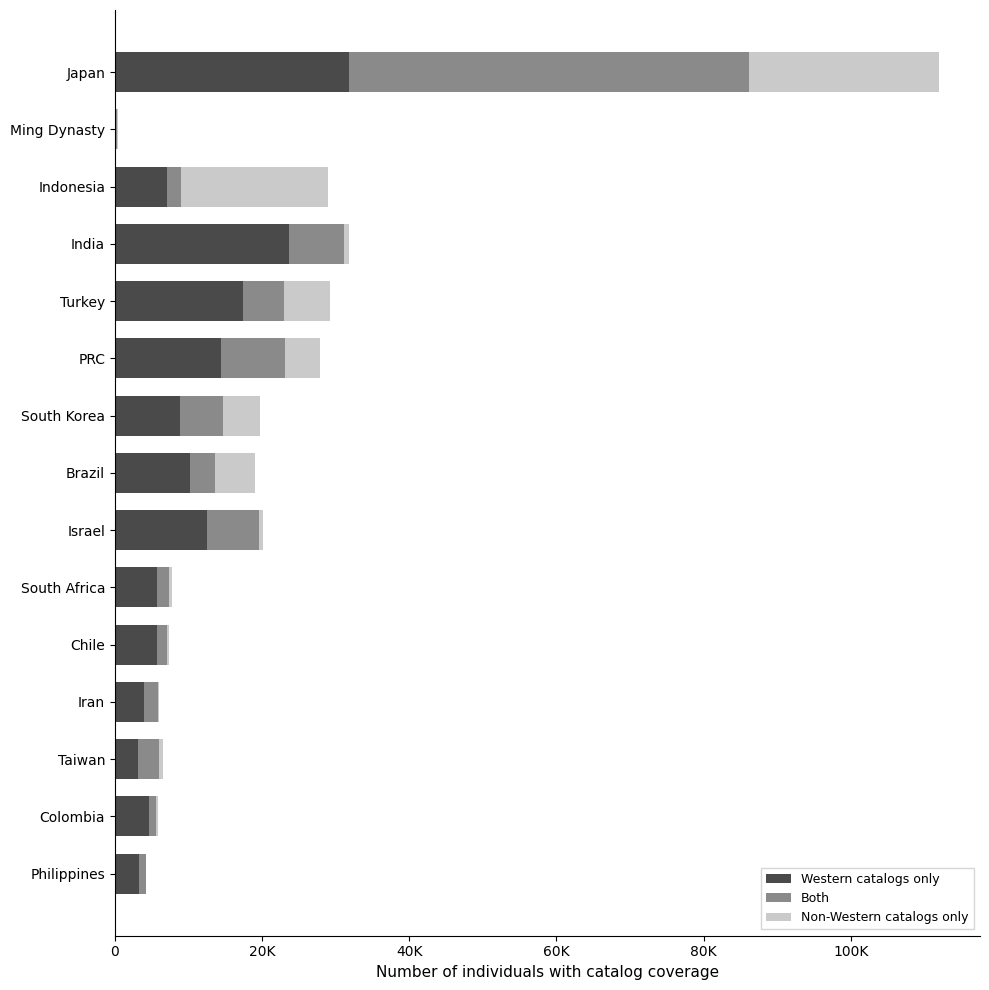

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
y = np.arange(len(labels))
height = 0.7

ax.barh(y, w_only, height=height, color='#4a4a4a', label='Western catalogs only')
ax.barh(y, both, height=height, left=w_only, color='#8a8a8a', label='Both')
ax.barh(y, nw_only, height=height, left=w_only + both, color='#cacaca', label='Non-Western catalogs only')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Number of individuals with catalog coverage', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
ax.legend(fontsize=9, loc='lower right', frameon=True, fancybox=False, edgecolor='#cccccc')
plt.tight_layout()
plt.show()

In [6]:
conn.close()